In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('House_Rent_Dataset.csv',usecols=['BHK','Rent','Size'])
df.sample(3)

,BHK,Rent,Size
3143,1,5000,250
958,2,40000,600
2805,2,15000,700


In [7]:
#df = df.iloc[:,:] another method for coloumns needed
df.shape

(4746, 3)

# ***TRAIN TEST SPLIT:***

In [21]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(df[['Size','BHK']],df['Rent'],test_size=0.2,random_state=0)

In [22]:
X_train.shape , X_test.shape

((3796, 2), (950, 2))

In [23]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# scaler.fit(X_train)
X_train_scaled[['BHK', 'Size']] = scaler.fit_transform(X_train[['BHK', 'Size']])
X_test_scaled[['BHK', 'Size']] = scaler.transform(X_test[['BHK', 'Size']])

# Optional: check first 5 rows
print("X_train_scaled:\n", X_train_scaled.head())
print("X_test_scaled:\n", X_test_scaled.head())


X_train_scaled:
           Size       BHK
4681 -0.415285 -0.092778
630  -0.494590 -0.092778
1742  0.377757  1.121651
3077 -0.637337 -1.307206
2996 -0.573894 -0.092778
X_test_scaled:
           Size       BHK
1332 -0.875250 -1.307206
4345  0.536366 -0.092778
4495 -0.098068 -0.092778
2473 -0.891111 -1.307206
3883  1.326236  1.121651


In [27]:
# Check mean and std after standardization
print("Means of X_train_scaled:\n", X_test_scaled[['BHK','Size']].mean())
print("Std devs of X_train_scaled:\n", X_test_scaled[['BHK','Size']].std())

Means of X_train_scaled:
 BHK     0.045284
Size    0.044851
dtype: float64
Std devs of X_train_scaled:
 BHK     1.051705
Size    1.028374
dtype: float64


In [28]:
np.round(X_train.describe(),1)

,Size,BHK
count,3796.0,3796.0
mean,961.8,2.1
std,630.6,0.8
min,10.0,1.0
25%,550.0,2.0
50%,850.0,2.0
75%,1200.0,3.0
max,8000.0,6.0


In [30]:
np.round(X_train_scaled.describe(),1)

,Size,BHK
count,3796.0,3796.0
mean,0.0,0.0
std,1.0,1.0
min,-1.5,-1.3
25%,-0.7,-0.1
50%,-0.2,-0.1
75%,0.4,1.1
max,11.2,4.8


# *EFFECT OF SCALING:*

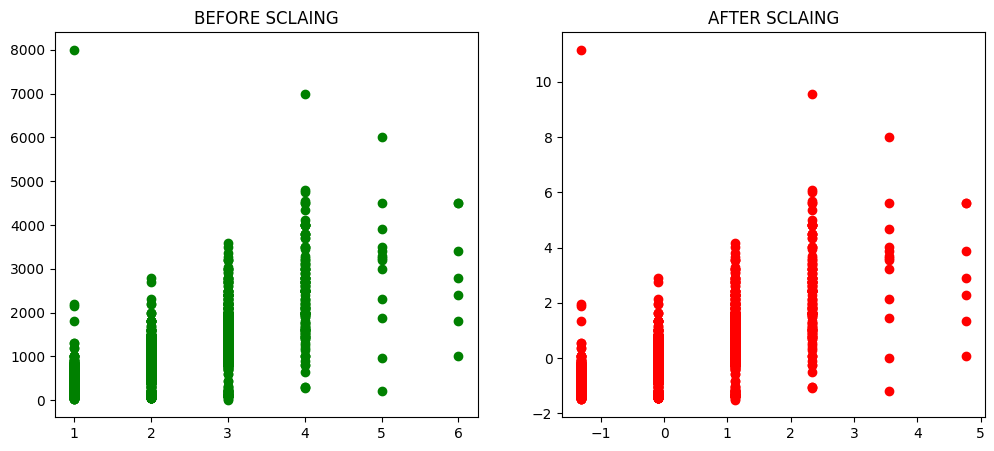

In [35]:
fig,(ax1,ax2) = plt.subplots(ncols = 2,figsize =(12,5))
ax1.scatter(X_train['BHK'],X_train['Size'],color = 'green')
ax1.set_title('BEFORE SCLAING')
ax2.scatter(X_train_scaled['BHK'],X_train_scaled['Size'],color = 'red')
ax2.set_title('AFTER SCLAING')
plt.show()

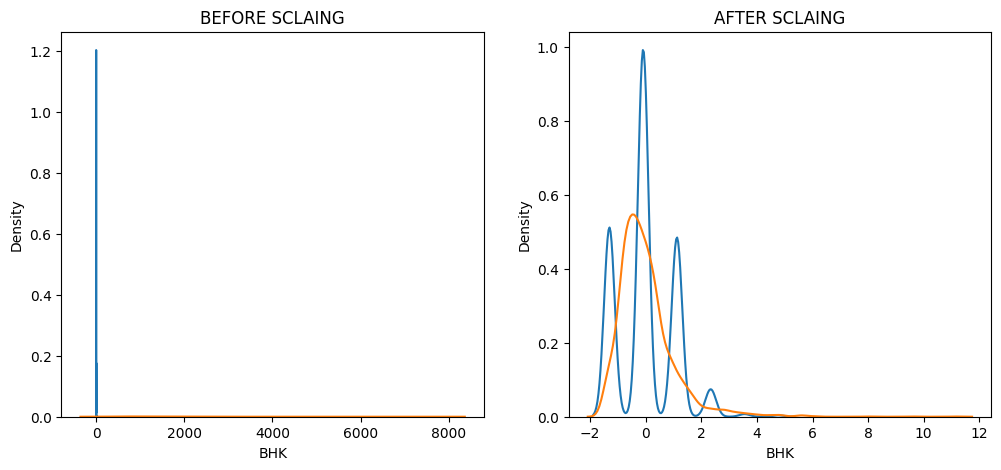

In [37]:
fig,(ax1,ax2) = plt.subplots(ncols = 2,figsize =(12,5))
sns.kdeplot(X_train['BHK'],ax=ax1)
sns.kdeplot(X_train['Size'],ax=ax1)
ax1.set_title('BEFORE SCLAING')
sns.kdeplot(X_train_scaled['BHK'],ax=ax2)
sns.kdeplot(X_train_scaled['Size'],ax=ax2)
ax2.set_title('AFTER SCLAING')
plt.show()

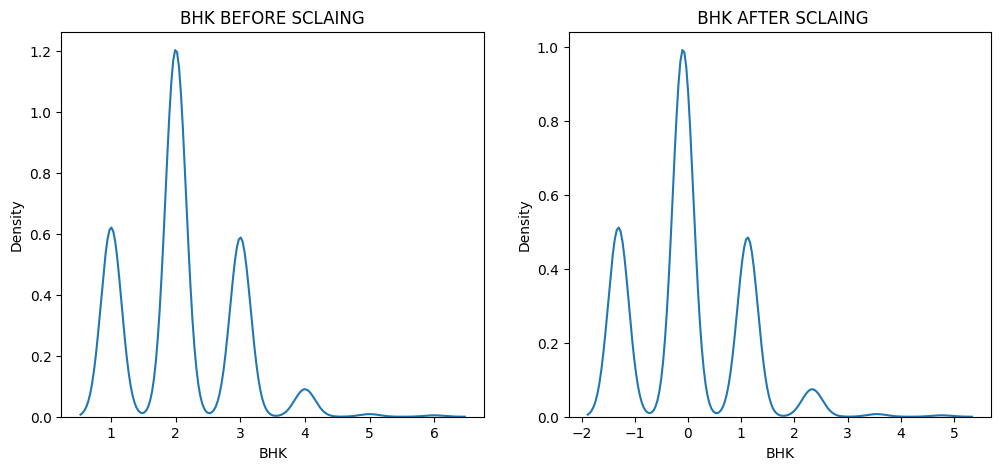

In [38]:
fig,(ax1,ax2) = plt.subplots(ncols = 2,figsize =(12,5))
ax1.set_title('BHK BEFORE SCLAING')
sns.kdeplot(X_train['BHK'],ax=ax1)
ax2.set_title(' BHK AFTER SCLAING')
sns.kdeplot(X_train_scaled['BHK'],ax=ax2)
plt.show() #Data remain the same but the scale is changed only same for Size

# WHY SCALING IS IMPORTANT

In [40]:
from sklearn.linear_model import LogisticRegression

In [44]:
lr = LogisticRegression()
lr_scaled = LogisticRegression()

In [46]:
lr.fit(X_train,Y_train)
lr_scaled.fit(X_train_scaled,Y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [47]:
y_pred = lr.predict(X_test)
y_pred_scaled = lr_scaled.predict(X_test_scaled)

In [49]:
from sklearn.metrics import accuracy_score

In [50]:
print("Actual" , accuracy_score(Y_test,y_pred))
print("Scaled" , accuracy_score(Y_test,y_pred_scaled)) #after scaling accuracy increased

Actual 0.05368421052631579
Scaled 0.07368421052631578


# EFFECT OF OUTLIERS:

In [51]:
df.describe()

,BHK,Rent,Size
count,4746.000000,4.746000e+03,4746.000000
mean,2.083860,3.499345e+04,967.490729
std,0.832256,7.810641e+04,634.202328
min,1.000000,1.200000e+03,10.000000
25%,2.000000,1.000000e+04,550.000000
50%,2.000000,1.600000e+04,850.000000
75%,3.000000,3.300000e+04,1200.000000
max,6.000000,3.500000e+06,8000.000000


In [54]:

new_row = pd.DataFrame({'BHK': [15], 'Size': [15000], 'Rent': [0]})

# Append the new row
df = pd.concat([df, new_row], ignore_index=True)

df.tail()

,BHK,Rent,Size
4743,3,35000,1750
4744,3,45000,1500
4745,2,15000,1000
4746,15,0,15000
4747,15,0,15000


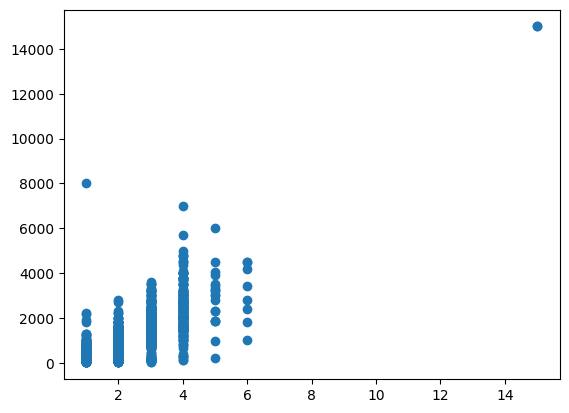

In [55]:
plt.scatter(df['BHK'],df['Size'])

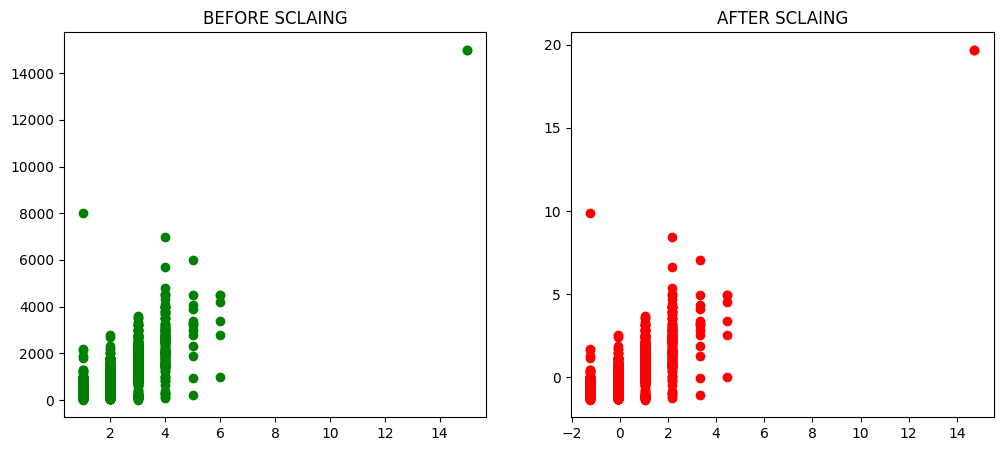

In [56]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(df[['Size','BHK']],df['Rent'],test_size=0.2,random_state=0)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# scaler.fit(X_train)
X_train_scaled[['BHK', 'Size']] = scaler.fit_transform(X_train[['BHK', 'Size']])
X_test_scaled[['BHK', 'Size']] = scaler.transform(X_test[['BHK', 'Size']])
fig,(ax1,ax2) = plt.subplots(ncols = 2,figsize =(12,5))
ax1.scatter(X_train['BHK'],X_train['Size'],color = 'green')
ax1.set_title('BEFORE SCLAING')
ax2.scatter(X_train_scaled['BHK'],X_train_scaled['Size'],color = 'red')
ax2.set_title('AFTER SCLAING')
plt.show()